# Lab Assignment3

Name:Sat Naing Tun  ID:st125333

Exercise


Train and test CIFAR-10 dataset on a New Network with the following criteria.

The new model should have at least 3 convolutional layers with Same Convolutions (We have done with Valid Convolutions in our exercise). Each convolution layer is followed by an activation layer implemented inside a respective sequential block.
Train on a GPU to have at least 80% validation accuracy and plot the loss & accuracy graphs. You have to somehow tune the hyperparameters in order to achieve such accuracy.
While training, find the optimal fit value for the batch size in your gpu. Show your GPU usage using nvidia-smi command.
Test and show the predicted images on at least 10 images.
Explain your training steps (including how you tune) and discuss about the result briefly.
Hint:

the dataset can be download as below.
you may use data augmentation (optional)
please use a research concept approach to explore and explain the result.

In [1]:
!nvidia-smi

Fri Oct  3 13:49:54 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   72C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os


print(os.getcwd()) ### Uncomment to get your current working directory
# root_path = '/content/drive/MyDrive/DLCV-Lab/' ### Uncomment and modify your root path if you are using own laptop
root_path=os.getcwd()
lab_path =  root_path + '/Lab03Assignment/'
if not os.path.exists(lab_path):
    print("No folder ", lab_path, 'exist. Creating a new folder...')
    os.mkdir(lab_path)
    print("New directory is created.")
else:
    print(lab_path, 'exists, do nothing')

/content
/content/Lab03Assignment/ exists, do nothing


In [3]:
import torch
import torch.cuda as cuda
import torch.nn as nn

from torch.autograd import Variable

from torchvision import datasets
from torchvision import transforms

# The functional module contains helper functions for defining neural network layers as simple functions
import torch.nn.functional as F

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [5]:
preprocess = transforms.Compose([
    transforms.Resize(32),
    transforms.CenterCrop(28),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))])

In [6]:

train_dataset = datasets.CIFAR10(root='./data', train=True,
                                             download=True, transform=preprocess)


train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [40000, 10000])

test_dataset = datasets.CIFAR10(root='./data', train=False,
                                            download=True, transform=preprocess)

Label of image above: 7


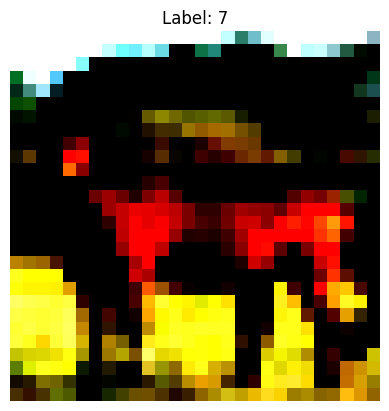

In [7]:
img, label = train_dataset[12]
print('Label of image above:', label)
img = img.numpy().transpose(1, 2, 0)
plt.imshow(img)
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()


In [8]:

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=4,
                                               shuffle=True, num_workers=2)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=4,
                                             shuffle=False, num_workers=2)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=4,
                                              shuffle=False, num_workers=2)

In [9]:
for data, label in train_dataloader:
    print(data.shape)
    print(label.shape)
    break

torch.Size([4, 3, 28, 28])
torch.Size([4])


In [10]:
train_transform = transforms.Compose([
    transforms.Resize(32),
    transforms.RandomCrop(28, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])


eval_transform = transforms.Compose([
    transforms.Resize(32),
    transforms.CenterCrop(28),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

In [25]:
class Cifar10_CNN_Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Flatten(),
            nn.Linear(256 * 3 * 3, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.net(x)




In [28]:
# The model
model = Cifar10_CNN_Model()

if cuda.is_available():
    model = model.cuda()

# Our loss function
criterion = nn.CrossEntropyLoss()

# Our optimizer
learning_rate = 0.01
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [29]:
print(model)

Cifar10_CNN_Model(
  (net): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout(p=0.2

In [30]:
num_epochs = 20

train_loss = []
valid_loss = []
train_accuracy = []
valid_accuracy = []

for epoch in range(num_epochs):

    ############################
    # Train
    ############################

    iter_loss = 0.0
    correct = 0
    iterations = 0

    model.train()

    for i, (items, classes) in enumerate(train_dataloader):

        items = Variable(items)
        classes = Variable(classes)

        # If GPU is available, move data to GPU
        if torch.cuda.is_available():
            items = items.cuda()
            classes = classes.cuda()

        optimizer.zero_grad()
        outputs = model(items)
        loss = criterion(outputs, classes)
        iter_loss += loss.item()
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == classes.data).sum().item()
        iterations += 1

    train_loss.append(iter_loss / iterations)
    train_accuracy.append(100 * correct / len(train_dataloader.dataset))

    ############################
    # Validate
    ############################

    val_loss = 0.0
    val_correct = 0
    val_iterations = 0

    model.eval()

    for i, (items, classes) in enumerate(val_dataloader):

        items = Variable(items)
        classes = Variable(classes)

        if torch.cuda.is_available():
            items = items.cuda()
            classes = classes.cuda()

        outputs = model(items)
        val_loss += criterion(outputs, classes).item()

        _, predicted = torch.max(outputs.data, 1)
        val_correct += (predicted == classes.data).sum().item()
        val_iterations += 1

    valid_loss.append(val_loss / val_iterations)
    valid_accuracy.append(100 * val_correct / len(val_dataloader.dataset))

    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"Train Loss: {train_loss[-1]:.4f}, Train Acc: {train_accuracy[-1]:.2f}%, "
          f"Val Loss: {valid_loss[-1]:.4f}, Val Acc: {valid_accuracy[-1]:.2f}%")


Epoch 1/20, Train Loss: 1.6863, Train Acc: 38.78%, Val Loss: 1.2027, Val Acc: 57.32%
Epoch 2/20, Train Loss: 1.2317, Train Acc: 57.17%, Val Loss: 0.9108, Val Acc: 68.10%
Epoch 3/20, Train Loss: 1.0299, Train Acc: 64.80%, Val Loss: 0.8242, Val Acc: 71.02%
Epoch 4/20, Train Loss: 0.9294, Train Acc: 68.43%, Val Loss: 0.7504, Val Acc: 73.84%
Epoch 5/20, Train Loss: 0.8540, Train Acc: 70.99%, Val Loss: 0.7348, Val Acc: 74.41%
Epoch 6/20, Train Loss: 0.7976, Train Acc: 72.92%, Val Loss: 0.6832, Val Acc: 76.43%
Epoch 7/20, Train Loss: 0.7484, Train Acc: 74.47%, Val Loss: 0.6424, Val Acc: 78.12%
Epoch 8/20, Train Loss: 0.7157, Train Acc: 75.88%, Val Loss: 0.6382, Val Acc: 78.58%
Epoch 9/20, Train Loss: 0.6802, Train Acc: 76.91%, Val Loss: 0.6140, Val Acc: 79.48%
Epoch 10/20, Train Loss: 0.6561, Train Acc: 78.17%, Val Loss: 0.6124, Val Acc: 79.27%
Epoch 11/20, Train Loss: 0.6356, Train Acc: 78.70%, Val Loss: 0.6010, Val Acc: 80.18%
Epoch 12/20, Train Loss: 0.6124, Train Acc: 79.64%, Val Loss: 0

In [31]:
# save the model
torch.save(model.state_dict(), lab_path+"model_Lab3Assignment.pth")
# for colab user
#torch.save(model.state_dict(), root_path + "lab03/model_epoch20.pth")

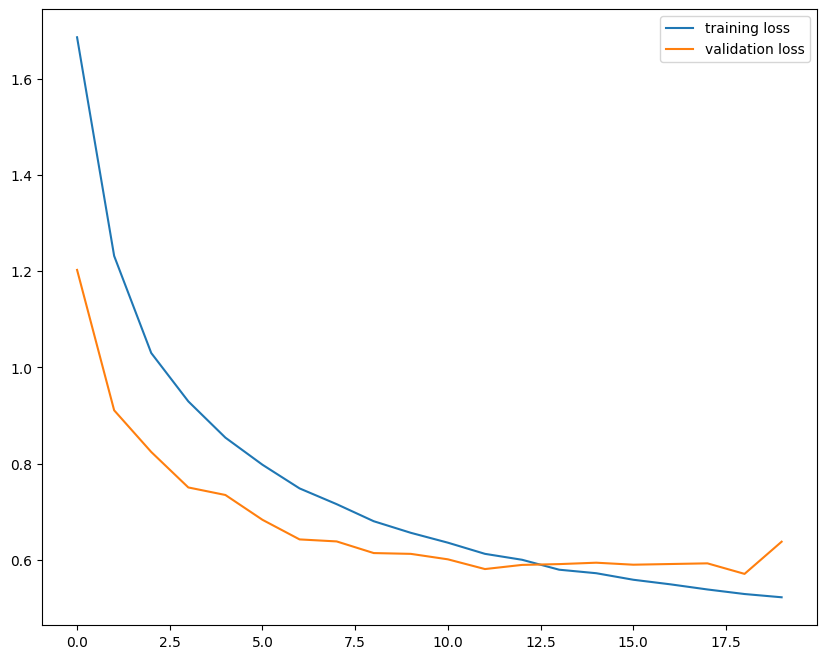

In [32]:
# Plot loss curves

f = plt.figure(figsize=(10, 8))
plt.plot(train_loss, label='training loss')
plt.plot(valid_loss, label='validation loss')
plt.legend()
plt.show()

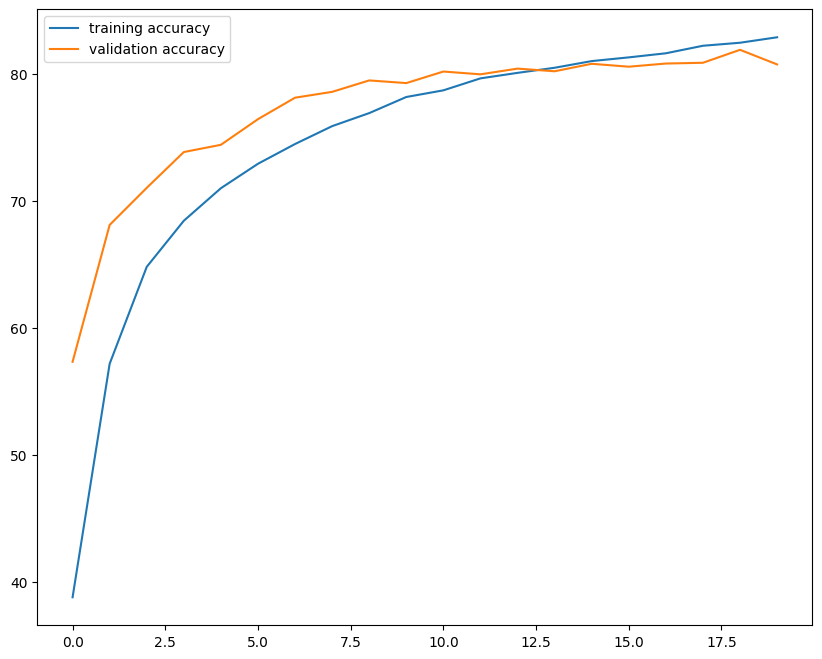

In [33]:
# Plot accuracy curves

f = plt.figure(figsize=(10, 8))
plt.plot(train_accuracy, label='training accuracy')
plt.plot(valid_accuracy, label='validation accuracy')
plt.legend()
plt.show()

In [34]:
def evaluate_accuracy(model, dataloader, dataset_name="Validation"):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"{dataset_name} Accuracy: {accuracy:.2f}%")
    return accuracy


val_accuracy = evaluate_accuracy(model, val_dataloader, "Validation")
test_accuracy = evaluate_accuracy(model, test_dataloader, "Test")

Validation Accuracy: 80.74%
Test Accuracy: 80.90%


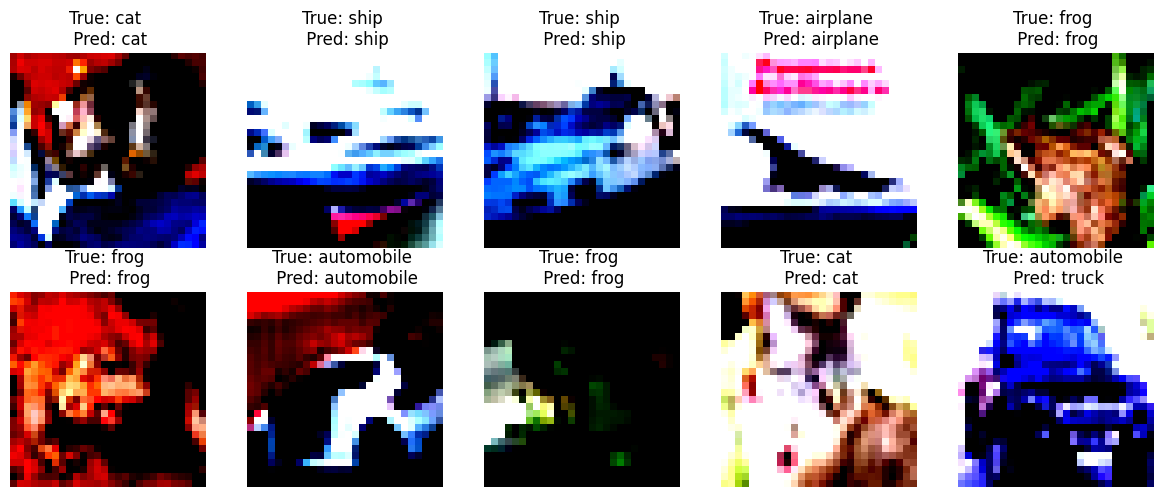

In [35]:
# CIFAR-10 class names
classes = test_dataset.classes

# Plot 10 test images with predictions
fig, axs = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    img, label = test_dataset[i]
    img_input = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_input)
        pred = torch.argmax(output, dim=1).item()

    img_np = img.numpy().transpose(1, 2, 0)
    axs[i//5, i%5].imshow(img_np)
    axs[i//5, i%5].set_title(f"True: {classes[label]} \n Pred: {classes[pred]}")
    axs[i//5, i%5].axis('off')

plt.tight_layout()
plt.show()